<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# Liga Data Science
## Prof. Eduardo Pécora

# Regressão Linear
Tempo estimado: **90** minutos

-----


# Predição de Custos em Saúde

# 1. Problema de Negócio
Uma operadora de plano de saúde deseja prever o custo anual de seus beneficiários com base em características demográficas e comportamentais.

Pergunta:

Quais fatores mais impactam o custo médico?

Objetivo:
- Entender os dados
- Construir um modelo de regressão linear
- Interpretar os coeficientes
- Gerar insights para decisão

# Bibliotecas

In [171]:
# Básicas
import pandas as pd
import numpy as np

#Gráficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Importação de dados

In [172]:
url = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/insurance.csv"
df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


 # 2. Entendimento dos dados

 ### Estrutura dos dados

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


 ### Estatísticas descritivas

In [174]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


 ### Qualidade dos dados

In [175]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# 3. Análise exploratória (Entendimento dos dados)

### Distribuição do custo

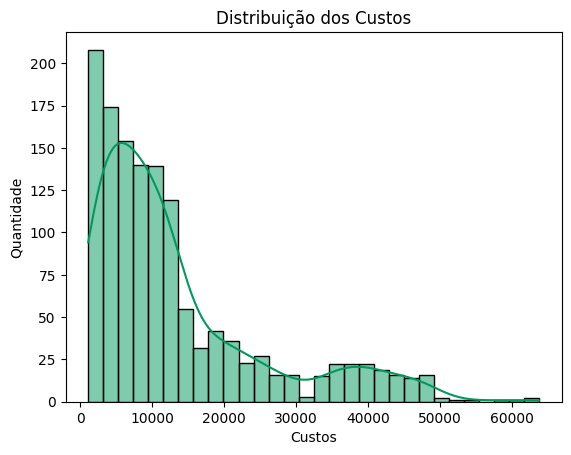

In [176]:
sns.histplot(df["charges"], kde=True, color="#00995D")
plt.title("Distribuição dos Custos")
plt.xlabel("Custos")
plt.ylabel("Quantidade")
plt.show()

### Relação idade vs custo

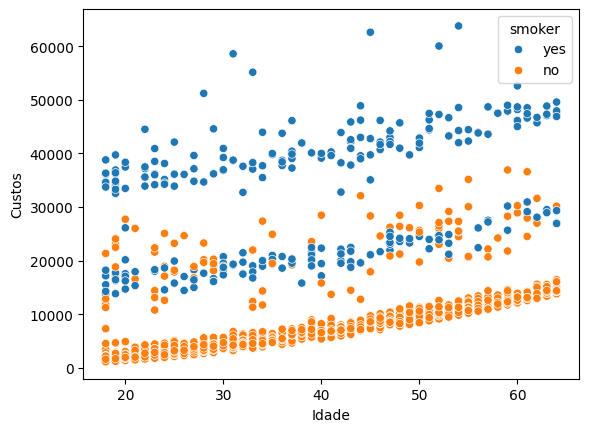

In [177]:
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.xlabel("Idade")
plt.ylabel("Custos")
plt.show()

### Boxplot fumante

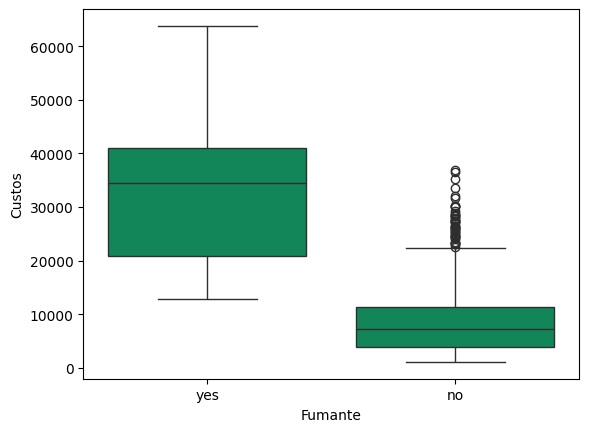

In [178]:
sns.boxplot(data=df, x="smoker", y="charges",color="#00995D")
plt.xlabel("Fumante")
plt.ylabel("Custos")
plt.show()

### Correlação

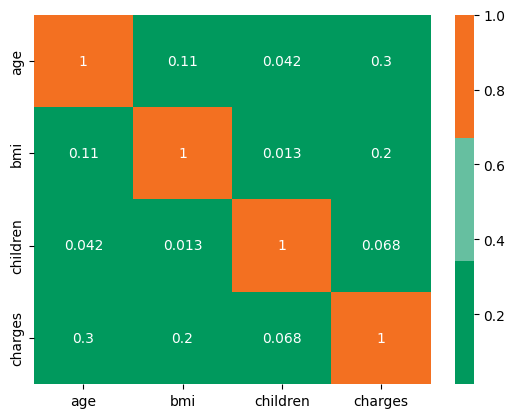

In [179]:
unimed_Colors = sns.color_palette(
    ["#00995D", "#66BFA0", "#F37021"],
    as_cmap=True
)

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap=unimed_Colors)
plt.show()

### Análise exploratória (Pair Plot)

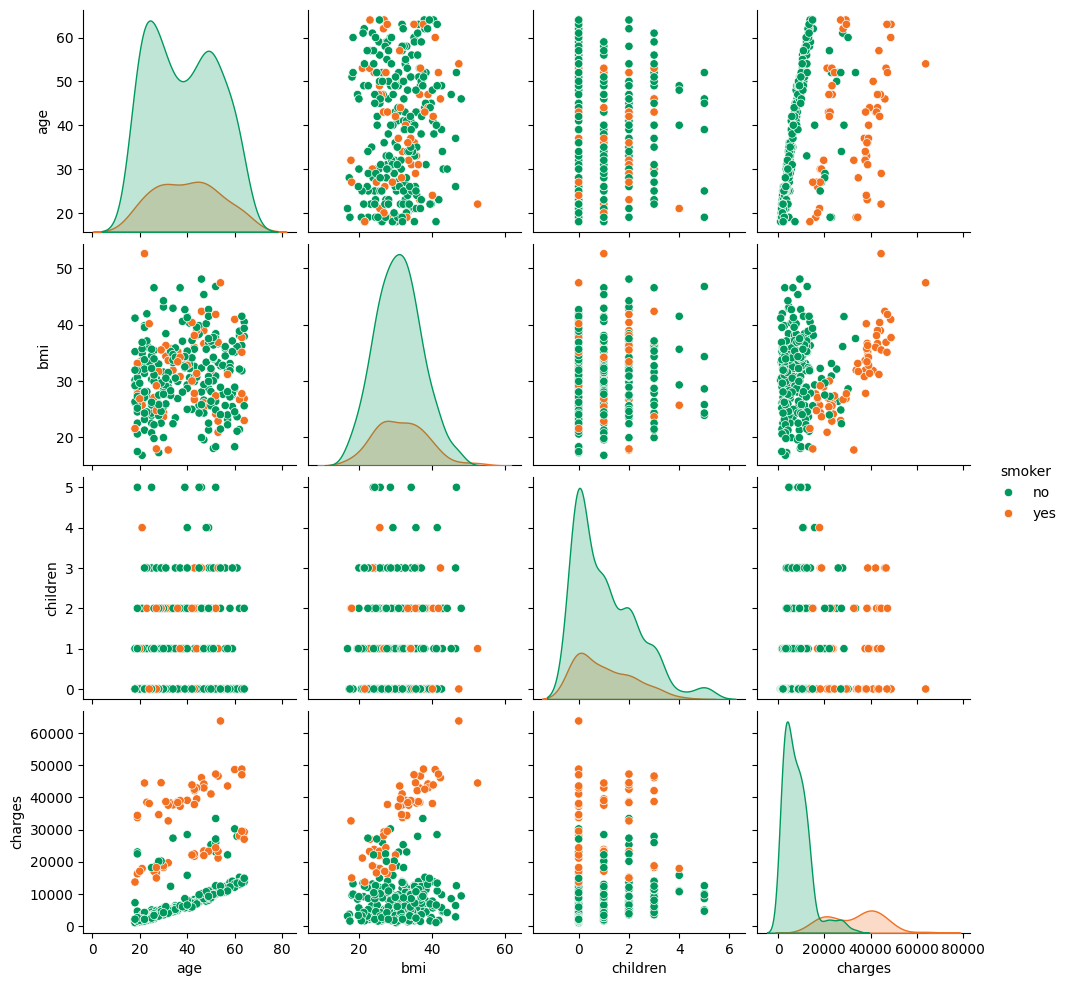

In [160]:
df_sample = df.sample(300, random_state=42)

#df_sample = df.copy()
palette = ["#00995D", "#F37021"]

sns.pairplot(
    df_sample,
    hue="smoker",   # cor por fumante (muito didático)
    diag_kind="kde",
    palette = palette
)

plt.show()

# 4. Preparação dos dados

### 4.1 Transformar as variáveis categóricas em numéricas

In [161]:
df = pd.get_dummies(df, drop_first=False)
df.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


### 4.2 Separar as variáveis independentes e dependentes (X e y)

In [162]:
X = df.drop("charges", axis=1)
y = df["charges"]

### 4.3 Separar em dados de treino e teste

In [163]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Modelo de Regressão Linear

In [164]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# 6. Avaliação

In [165]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 4181.194473753647
R2: 0.7835929767120722


### 6.1 Real vs Previsto

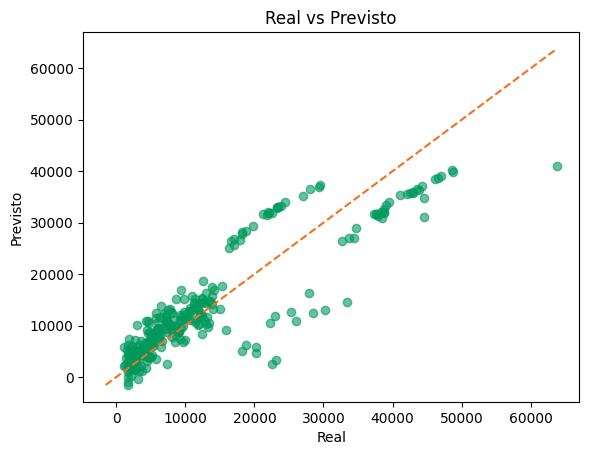

In [187]:
plt.scatter(y_test, y_pred, alpha=0.6, color = "#00995D")

# linha x = y
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())

plt.plot([min_val, max_val], [min_val, max_val], color="#F37021", linestyle='--')

plt.xlabel("Real")
plt.ylabel("Previsto")
plt.title("Real vs Previsto")
plt.show()

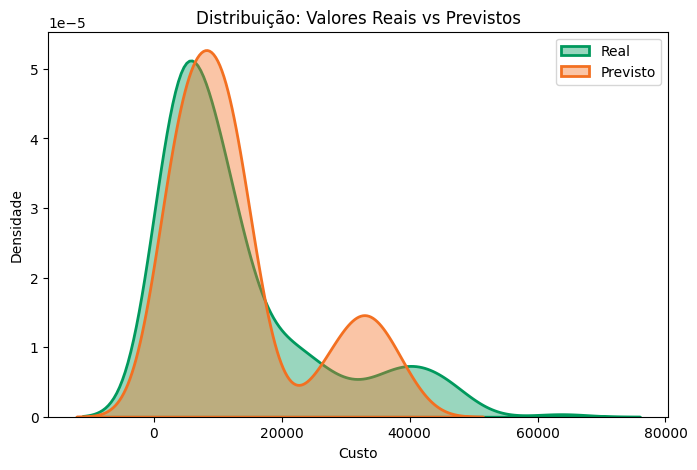

In [183]:
plt.figure(figsize=(8,5))

sns.kdeplot(y_test, label="Real", fill=True, color="#00995D", alpha=0.4, linewidth=2)
sns.kdeplot(y_pred, label="Previsto", fill=True, color="#F37021", alpha=0.4, linewidth=2)

plt.title("Distribuição: Valores Reais vs Previstos")
plt.xlabel("Custo")
plt.ylabel("Densidade")
plt.legend()
plt.show()

### 6.2 Coeficientes

In [168]:
coef = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": model.coef_
}).sort_values(by="Coeficiente", ascending=False)

coef

,Variável,Coeficiente
6,smoker_yes,11825.564428
7,region_northeast,459.585244
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
8,region_northwest,88.907918
3,sex_female,9.295846
4,sex_male,-9.295846
9,region_southeast,-198.279052
10,region_southwest,-350.214110


### 6.3 Gráfico interativo

In [184]:
fig = px.scatter(
    x=y_test,
    y=y_pred,
    labels={"x": "Real", "y": "Previsto"},
    color_discrete_sequence=["#00995D"]  # Verde UNIMED
)

# Linha de referência (y = x)
fig.add_shape(
    type="line",
    x0=min(y_test),
    y0=min(y_test),
    x1=max(y_test),
    y1=max(y_test),
    line=dict(color="#F37021", width=3)  # Laranja UNIMED
)

fig.update_layout(
    title="Real vs Previsto",
    template="simple_white"
)

fig.show()

### 6.4 Análise de Resíduos

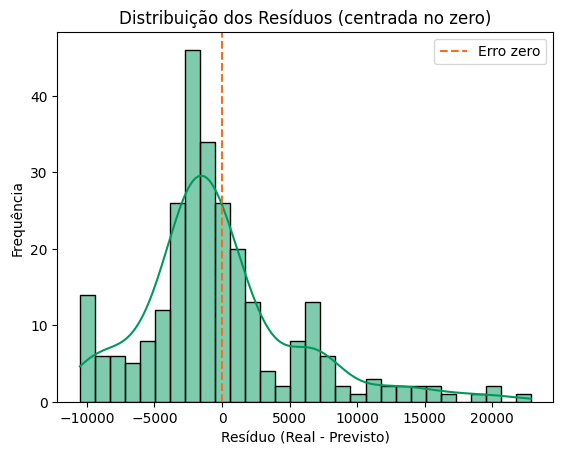

In [185]:
residuals = y_test - y_pred

sns.histplot(residuals, bins=30, kde=True, color = "#00995D")

plt.axvline(0, color='#F37021', linestyle='--', label='Erro zero')

plt.title("Distribuição dos Resíduos (centrada no zero)")
plt.xlabel("Resíduo (Real - Previsto)")
plt.ylabel("Frequência")

plt.legend()
plt.show()

### Interpretação

* positivos → subestimamos custo
* negativos → superestimamos custo

# 7. Conclusões

## Insights principais

- Fumantes apresentam custo significativamente maior
- Idade tem impacto linear relevante
- Modelo consegue capturar boa parte da variabilidade

## Aplicações

- Segmentação de risco
- Programas de prevenção
- Precificação

## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!

_______

## Autor

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>


## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 04-04-2026       | 1.0     | Eduardo Pecora    | Estrutura de Aula               |

<hr>

## <h3 align="center"> (c) LDS / UFPR 2026. All rights reserved. <h3/>